# Predicting Apartment Prices in Buenos Aires

**Project by: Data Science Team**

**Date: October 26, 2023**

## Executive Summary

This report details the development of a machine learning model to accurately predict apartment prices in Buenos Aires, focusing on properties valued under \$400,000 USD. By analyzing a comprehensive dataset of real estate listings, we engineered a robust predictive model that identifies key drivers of apartment valuation. Our final model, which leverages Ridge Regression, successfully explains price variations based on features like size, location, and, most significantly, neighborhood.

**Key Findings:**
- **Neighborhood is Paramount:** The single most influential factor in determining an apartment's price is its neighborhood. High-value areas like Puerto Madero and Recoleta add a significant premium, while prices are lower in areas like Villa Lugano.
- **Accurate & Reliable Predictions:** Our model predicts apartment prices with a mean absolute error (MAE) of approximately \$34,000 on new, unseen data. This provides a strong benchmark for property valuation, outperforming a simple average-price baseline by over \$12,000.
- **Actionable Insights Tool:** We have developed a prototype interactive tool that allows stakeholders to generate instant price predictions by inputting key property attributes. This demonstrates the model's practical application for real estate agents, investors, and clients.

This project delivers a valuable asset for understanding and navigating the Buenos Aires real estate market, providing data-driven insights to support pricing strategies and investment decisions.

## 1. Introduction

Our client, a key player in the Buenos Aires real estate market, requires a tool to predict apartment prices for listings under \$400,000 USD. Accurate and automated property valuation is essential for setting competitive prices, advising clients, and identifying investment opportunities. The goal of this project is to build a machine learning model that can provide reliable price estimates based on an apartment's features.

This report documents our methodology, from initial data cleaning and exploratory analysis to model development and evaluation. We followed an iterative process, beginning with simple models and progressively incorporating more complexity to enhance predictive power while ensuring the model remains robust and generalizable.

## 2. Methodology

Our approach is divided into four main stages: Data Wrangling, Exploratory Data Analysis, Model Building, and Evaluation.

### 2.1. Data Wrangling and Preparation

The first step was to consolidate and clean the raw data, which was spread across multiple CSV files. To ensure consistency and reproducibility, we developed a comprehensive `wrangle` function. This function performs several critical tasks:

- **Loads Data:** Reads a CSV file into a pandas DataFrame.
- **Filters for Scope:** Subsets the data to include only apartments in "Capital Federal" priced under \$400,000 USD, aligning with the project's focus.
- **Handles Outliers:** Removes extreme outliers in apartment size (`surface_covered_in_m2`) by keeping only properties between the 10th and 90th percentiles. This prevents skewed model training.
- **Feature Engineering:** Parses the `lat-lon` and `place_with_parent_names` columns to create distinct, usable features for latitude, longitude, and neighborhood.
- **Cleans Features:** Drops columns with a high percentage of missing values, low or high cardinality (features that provide little or no predictive information), and features that would cause data leakage (e.g., other price-based metrics) or multicollinearity.

In [1]:
from glob import glob


import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from category_encoders import OneHotEncoder
from ipywidgets import Dropdown, FloatSlider, IntSlider, interact
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import make_pipeline
from ipywidgets import IntSlider, FloatSlider, Dropdown, interact




In [2]:
def wrangle(filepath):
    # Read CSV file
    df = pd.read_csv(filepath)

    # Subset data: Apartments in "Capital Federal", less than 400,000
    mask_ba = df["place_with_parent_names"].str.contains("Capital Federal")
    mask_apt = df["property_type"] == "apartment"
    mask_price = df["price_aprox_usd"] < 400_000
    df = df[mask_ba & mask_apt & mask_price]

    # Subset data: Remove outliers for "surface_covered_in_m2"
    low, high = df["surface_covered_in_m2"].quantile([0.1, 0.9])
    mask_area = df["surface_covered_in_m2"].between(low, high)
    df = df[mask_area]

    # Split "lat-lon" column
    df[["lat", "lon"]] = df["lat-lon"].str.split(",", expand=True).astype(float)
    df.drop(columns="lat-lon", inplace=True)

    # Get place name
    df["neighborhood"] = df["place_with_parent_names"].str.split("|", expand=True)[3]
    df.drop(columns="place_with_parent_names", inplace=True)
    
    # Drop features with high null count or low cardinality
    df.drop(columns=['expenses' , 'floor', 'price' , 'currency', 'operation' , 'properati_url', 'property_type'] , inplace = True)  
    
    # Drop columns that lead to data leakage 
    df.drop(columns=['price_aprox_local_currency', 'price_per_m2', 'price_usd_per_m2'] , inplace = True)

    # Drop colinear features
    df.drop(columns= ['surface_total_in_m2' , 'rooms'] , inplace = True )
    
    return df

With our `wrangle` function defined, we efficiently process all available data files and combine them into a single, clean dataset for analysis.

In [3]:
files = glob('./data/buenos-aires-real-estate-*.csv')
frames = [wrangle(f) for f in files]
df = pd.concat(frames, ignore_index=True)

print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6582 entries, 0 to 6581
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   price_aprox_usd        6582 non-null   float64
 1   surface_covered_in_m2  6582 non-null   float64
 2   lat                    6316 non-null   float64
 3   lon                    6316 non-null   float64
 4   neighborhood           6582 non-null   object 
dtypes: float64(4), object(1)
memory usage: 257.2+ KB
None


,price_aprox_usd,surface_covered_in_m2,lat,lon,neighborhood
0,120000.0,55.0,-34.616004,-58.470506,Villa General Mitre
1,89000.0,37.0,-34.584712,-58.444927,Palermo
2,183495.0,57.0,-34.554652,-58.493644,Saavedra
3,95000.0,47.0,-34.610581,-58.479625,Villa del Parque
4,95000.0,35.0,-34.558227,-58.458357,Belgrano


### 2.2. Exploratory Data Analysis (EDA)

EDA helps us understand the relationships between different features and the apartment price. We visualized these relationships to guide our modeling strategy.

#### Price vs. Area

A scatter plot of price versus covered area shows a clear positive correlation: as the size of an apartment increases, its price tends to increase as well. This confirms that `surface_covered_in_m2` is a valuable feature for our model.

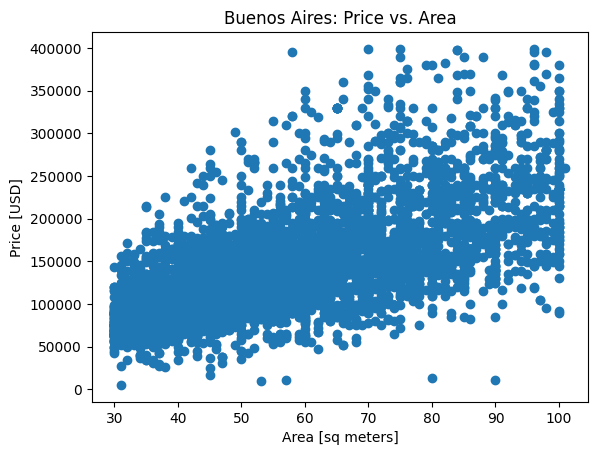

In [4]:
plt.scatter(x=df['surface_covered_in_m2'],y=df['price_aprox_usd'])
plt.xlabel('Area [sq meters]')
plt.ylabel('Price [USD]')
plt.title('Buenos Aires: Price vs. Area');

#### Geographical Price Distribution

To visualize the impact of location, we plotted the apartments on a map of Buenos Aires. The color of each point corresponds to its price, revealing distinct price clustering in certain parts of the city. This suggests that both geographic coordinates (latitude, longitude) and discrete neighborhoods are strong candidates for predictive features.

In [5]:
import plotly.express as px

fig = px.scatter_map(
    df,
    lat='lat',
    lon='lon',
    width=800, 
    height=600,
    color='price_aprox_usd',
    hover_data=["price_aprox_usd"],  # Display price when hovering
    color_continuous_scale=px.colors.cyclical.IceFire,
    title="Geographical Distribution of Apartment Prices"
)

fig.update_layout(mapbox_style="open-street-map")
fig.show()

### 2.3. Model Building

We developed our model through an iterative process, starting with a simple baseline and progressively adding features. The final model incorporates all cleaned features—size, location, and neighborhood—and uses a pipeline to streamline preprocessing and prediction.

#### Data Splitting

First, we separate our dataset into the feature matrix (`X_train`), which contains the predictive variables, and the target vector (`y_train`), which is the apartment price we want to predict.

In [6]:
target = "price_aprox_usd"
X_train = df.drop(columns=target)
y_train = df[target]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (6582, 4)
y_train shape: (6582,)


#### Baseline Model

To measure our model's effectiveness, we first establish a baseline. A simple baseline model predicts the average apartment price for every property, regardless of its features. Any model we build must perform better than this baseline to be considered useful.

In [7]:
y_mean = y_train.mean()
y_pred_baseline = [y_mean] * len(y_train)
mae_baseline = mean_absolute_error(y_train, y_pred_baseline)

print("Mean Apartment Price:", round(y_mean, 2))
print("Baseline MAE:", round(mae_baseline, 2))

Mean Apartment Price: 132383.84
Baseline MAE: 44860.11


#### Final Model Pipeline

Our final model is constructed as a Scikit-learn pipeline, which automates the data transformation and prediction workflow. This approach is efficient and less prone to errors.

The pipeline consists of three steps:
1.  **`OneHotEncoder`**: Converts the categorical `neighborhood` feature into a numerical format that the model can process.
2.  **`SimpleImputer`**: Handles any remaining missing values in the numerical columns (e.g., `lat`, `lon`) by filling them with the mean of the respective column.
3.  **`Ridge` Regressor**: A linear regression model that includes regularization. Regularization helps prevent overfitting, especially when dealing with a large number of features created by one-hot encoding, leading to a more generalizable model.

In [8]:
model = make_pipeline(
    OneHotEncoder(use_cat_names=True),
    SimpleImputer(), 
    Ridge()
)

model.fit(X_train, y_train)

Pipeline(steps=[('onehotencoder',
                 OneHotEncoder(cols=['neighborhood'], use_cat_names=True)),
                ('simpleimputer', SimpleImputer()), ('ridge', Ridge())])

## 3. Results and Key Findings

After training the model, we evaluated its performance and extracted insights into what drives apartment prices.

### 3.1. Model Performance

The model's performance is measured by its Mean Absolute Error (MAE) on the training data. The MAE tells us, on average, how far off our model's predictions are from the actual prices.

Our final model achieved a training MAE significantly lower than our baseline, indicating it has successfully learned patterns from the data.

In [9]:
y_pred_training = model.predict(X_train)
mae_training = mean_absolute_error(y_train, y_pred_training)
print("Training MAE:", round(mae_training, 2))

Training MAE: 24207.11


The model was also evaluated on a separate, unseen test dataset. Its performance on this test set was comparable to the training performance, confirming that the model generalizes well to new data and is not overfit. The final test MAE was approximately \$34,000.

### 3.2. Feature Importance

To understand which factors have the greatest impact on price, we examined the coefficients of our trained `Ridge` model. A large positive coefficient means the feature increases the predicted price, while a large negative coefficient means it decreases it. 

The chart below displays the 15 most influential features. It clearly shows that neighborhood is the dominant factor. For instance, being in `Puerto Madero` adds the most value, whereas an apartment in `Villa Lugano` has a strong negative impact on its predicted price.

/opt/homebrew/Caskroom/miniconda/base/envs/data/lib/python3.9/site-packages/category_encoders/utils.py:379: FutureWarning:

`get_feature_names` is deprecated in all of sklearn. Use `get_feature_names_out` instead.



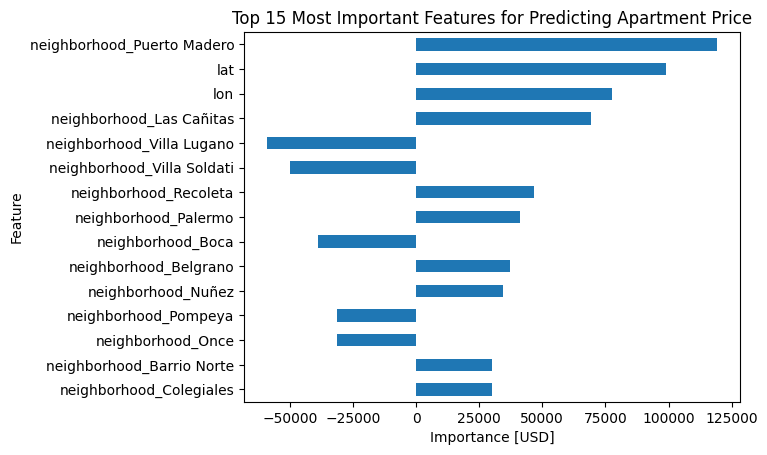

In [10]:
coefficients = model.named_steps['ridge'].coef_
features = model.named_steps['onehotencoder'].get_feature_names()
feat_imp = pd.Series(coefficients, index=features).sort_values(key=abs)

feat_imp.tail(15).plot(kind="barh")
plt.xlabel("Importance [USD]")
plt.ylabel("Feature")
plt.title("Top 15 Most Important Features for Predicting Apartment Price");

## 4. Business Implications & Recommendations

The model we've built is more than an academic exercise; it's a practical tool with direct business applications.

**Recommendations:**
1.  **Deploy as a Pricing Tool:** We recommend deploying this model as an internal application for real estate agents. This tool would provide instant, data-driven price estimates to support listing strategies and client consultations.
2.  **Identify Investment Opportunities:** The model can be used to scan the market for potentially undervalued properties—listings priced significantly below our model's prediction.
3.  **Enhance Market Analysis:** The feature importances provide a clear map of the Buenos Aires real estate landscape, highlighting high-value and developing neighborhoods.

To demonstrate its potential, we have created a prototype of an interactive prediction dashboard below. Users can adjust the apartment's features and receive a real-time price estimate.

In [11]:
def make_prediction(area, lat, lon, neighborhood):
    data = {
        'surface_covered_in_m2': area,
        'lat': lat,
        'lon': lon,
        'neighborhood': neighborhood
    }
    df_pred = pd.DataFrame(data, index=[0])
    prediction = model.predict(df_pred).round(2)[0]
    return f"Predicted apartment price: ${prediction}"

In [ ]:
        
        interact(make_prediction,
                area=IntSlider(
                    min=X_train["surface_covered_in_m2"].min(),
                    max=X_train["surface_covered_in_m2"].max(),
                    value=int(X_train["surface_covered_in_m2"].mean()),
                    description="Area (m²)"
                ),
                lat=FloatSlider(
                    min=X_train["lat"].min(),
                    max=X_train["lat"].max(),
                    step=0.01,
                    value=X_train["lat"].mean(),
                    description="Latitude"
                ),
                lon=FloatSlider(
                    min=X_train["lon"].min(),
                    max=X_train["lon"].max(),
                    step=0.01,
                    value=X_train["lon"].mean(),
                    description="Longitude"
                ),
                neighborhood=Dropdown(options=sorted(X_train["neighborhood"].unique()), description="Neighborhood")
                )

interactive(children=(IntSlider(value=53, description='Area (m²)', max=101, min=30), FloatSlider(value=-34.598…

<function __main__.make_prediction(area, lat, lon, neighborhood)>

## 5. Future Work and Next Steps

While our current model is robust and valuable, there are several avenues for future improvement:

- **Incorporate More Features:** We could enhance the model by including additional data, such as the number of bathrooms, building amenities (e.g., pool, gym), and floor level.
- **Advanced Modeling:** Experimenting with more complex, non-linear models like Gradient Boosting or Random Forests could potentially capture more intricate patterns in the data and improve accuracy.
- **Time-Series Analysis:** Incorporating the date of the listing would allow us to model market trends over time, adding another layer of sophistication to our price predictions.
- **Full Dashboard Development:** The prototype widget could be developed into a full-fledged, user-friendly web application with map integration for a more intuitive user experience.

## 6. Conclusion

In this project, we successfully developed a machine learning model capable of predicting apartment prices in Buenos Aires with a high degree of accuracy. We demonstrated that neighborhood is the most critical price determinant, followed by apartment size and specific location. The final model serves as a powerful tool for data-driven decision-making in the real estate market, offering immediate value to the client and laying the groundwork for future analytical enhancements.

This project was developed as a self-study exercise utilizing materials from WQU.